## Nội dung

- Feature engineering
- Phân cụm: KMeans, DBSCAN
- Kết hợp phân cụm và phân tích mô tả
- Kết hợp PCA và phân cụm
- Tập dữ liệu:
   1. Customer Personality Analysis (nguồn: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis)
   2. Taxi geolocation (nguồn: https://www.coursera.org/projects/clustering-geolocation-data-intelligently-python)

#### Cài đặt thư viện

In [67]:
! pip install folium
! pip install kneed
! pip install yellowbrick
! pip install kneed

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


^C
Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### A. Customer Personality Analysis

#### A1. Đọc dữ liệu

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
pd.set_option('display.max_columns', None)
customer_data = pd.read_csv('data/marketing_campaign.csv',
                           delimiter='\t', index_col='ID')
customer_data.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


#### A2. Làm sạch
- Làm sạch dữ liệu.
- Trích xuất đặc trưng (đọc thêm: https://machinelearningcoban.com/general/2017/02/06/featureengineering/)

In [ ]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2240 entries, 5524 to 9405
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   object 
 2   Marital_Status       2240 non-null   object 
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   object 
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   int

Dữ liệu khá sạch và chỉ có 1 số lượng nhỏ income bị thiếu dữ liệu, có thể xử lý bằng cách thêm vào mean. Mã hoá 1 số đặc trưng kiểu loại.

In [ ]:
# TODO, Xử lý dữ liệu khuyết cho Income bằng cách thêm mean

#### A3. Feature engineering

In [ ]:
import datetime

Đầu tiên là dữ liệu liên quan ngày tháng.

- `Year_Birth` không phải là đặc trưng lý tưởng cho bài toán này, ta sẽ chuyển nó sang thành tuổi `Age` (tính từ hiện tại)

In [ ]:
# Trích xuất tuổi từ đặc trưng năm sinh
# hint: 2022 - x
customer_data['Age'] = 2022 - customer_data['Year_Birth']

- `Days_Since_Customer`, tương tự như `Year_Birth`, nên được chuyển thành số ngày đã tham gia `Enroll_days`.

In [ ]:
# Đặc trưng 'Days_Since_Customer' ~ ngày tham gia, biến đổi thành số lượng ngày đã tham gia
import datetime

# Thêm dayfirst=True và format='mixed' để xử lý định dạng ngày không đồng nhất
customer_data['Dt_Customer'] = pd.to_datetime(
    customer_data['Dt_Customer'], dayfirst=True, format='mixed')

now = datetime.datetime.now()
customer_data['Enroll_days'] = (now - customer_data['Dt_Customer']).dt.days

- Các đặc trưng `Marital_Status`, `Kidhome`, `Teenhome` có thể được gom lại 1 thuộc tính duy nhất --> cô động hơn

In [ ]:
# Tạo ra đặc trưng Fam_size (số người trong gia đình)
# bằng cách gộp các đặc trưng: Martial_Status, Kidhome, Teenhome
marital_map = {
    'Absurd': 1, 'Alone': 1,
    'YOLO': 1, 'Single': 1,
    'Married': 2, 'Together': 2,
    'Widow': 1, 'Divorced': 1
} # married/together->2 người, khác-> 1 người
# Ánh ánh giá trị Marital_Status thành số người (1 hoặc 2) bằng map()
customer_data['Marital_Status'] = customer_data['Marital_Status'].map(
    marital_map
)

# Tính tổng số người trong gia đình = Hôn nhân + Trẻ em (Kidhome) + Thiếu niên (Teenhome)
customer_data['Fam_Size'] = (customer_data['Marital_Status']+ customer_data['Kidhome']+ customer_data['Teenhome']
)

- Gom các đặc trưng `AcceptedCmpX` thành 1 đặc trưng `Num_Accepted` (tổng)
- Làm tương tự cho các đặc trưng MntX, gom thành đặc trưng `MntTotal`

In [ ]:
# Num_Accepted = AcceptedCmp1 + AcceptedCmp2 + ...
customer_data['Num_Accepted'] = (customer_data['AcceptedCmp1']
    + customer_data['AcceptedCmp2']
    + customer_data['AcceptedCmp3']
    + customer_data['AcceptedCmp4']
    + customer_data['AcceptedCmp5']
    + customer_data['Response']
)
customer_data['Num_Accepted']

ID
5524     1
2174     0
4141     0
6182     0
5324     0
        ..
10870    0
4001     1
7270     1
8235     0
9405     1
Name: Num_Accepted, Length: 2240, dtype: int64

In [ ]:
# Có thể gộp các đặc trưng MntXXX thành 1 thuộc tính duy nhất (tính tổng)
customer_data['MntTotal'] = (
    customer_data['MntWines']
    + customer_data['MntFruits']
    + customer_data['MntMeatProducts']
    + customer_data['MntFishProducts']
    + customer_data['MntSweetProducts']
    + customer_data['MntGoldProds']
)

#### A4. Phân tích EDA

In [ ]:
customer_data.describe()

,Year_Birth,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,1.644643,52247.251354,0.444196,0.506250,2013-07-10 10:01:42.857142784,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107,53.194196,4830.582143,2.595089,0.446875,605.798214
min,1893.000000,1.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,26.000000,4477.000000,1.000000,0.000000,5.000000
25%,1959.000000,1.000000,35303.000000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,45.000000,4657.750000,2.000000,0.000000,68.750000
50%,1970.000000,2.000000,51381.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,52.000000,4832.500000,3.000000,0.000000,396.000000
75%,1977.000000,2.000000,68522.000000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,63.000000,5006.000000,3.000000,1.000000,1045.500000
max,1996.000000,2.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,129.000000,5176.000000,5.000000,5.000000,2525.000000
std,11.984069,0.478728,25173.076661,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274,11.984069,202.122512,0.906959,0.890543,602.249288


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

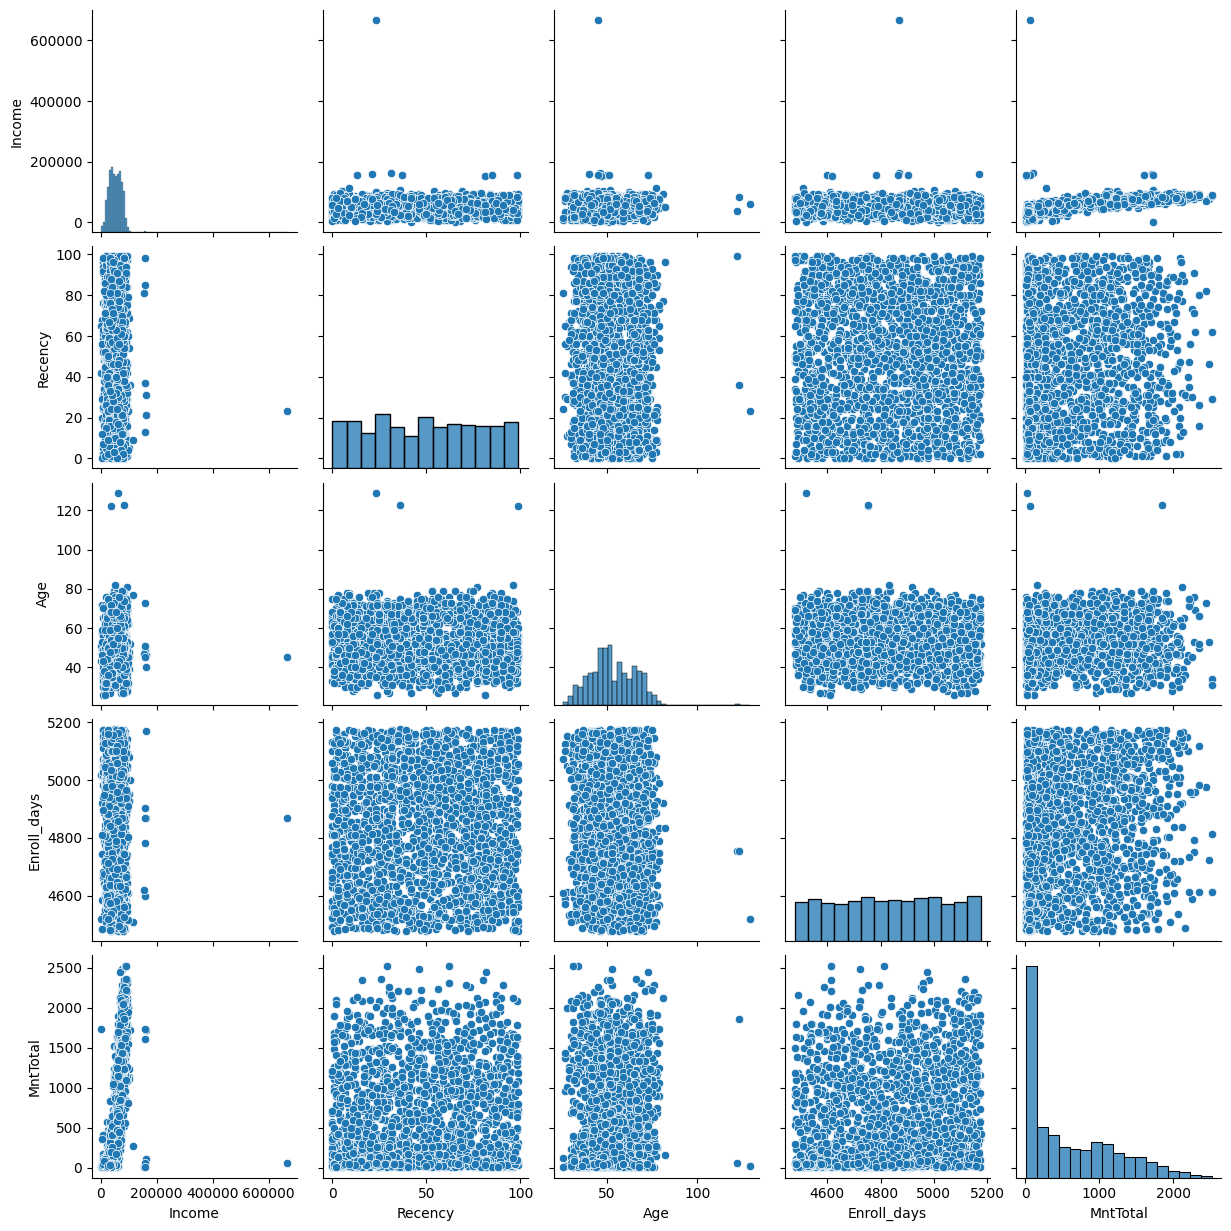

In [ ]:
plot_cols = ['Income', 'Recency', 'Age', 'Enroll_days', 'MntTotal']
# TODO - vẽ pair plot
sns.pairplot(customer_data[plot_cols])
plt.show()

In [ ]:
# TODO - xử lý nhiễu (nếu có)
# Lọc bỏ các điểm dữ liệu nhiễu vô lý
customer_data = customer_data[customer_data['Age'] < 100]
customer_data = customer_data[customer_data['Income'] < 600000]

print('Kích thước dữ liệu sau khi lọc nhiễu:', customer_data.shape)

Kích thước dữ liệu sau khi lọc nhiễu: (2212, 33)


In [ ]:
import copy
df = customer_data.copy()

# Drop các cột không quan trọng
df.drop([
    'Dt_Customer', 'Year_Birth',
    'Kidhome', 'Teenhome', 'Marital_Status',
    'Z_CostContact', 'Z_Revenue',
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
    'AcceptedCmp4','AcceptedCmp5',
    'Complain', 'Response', 'Education', 'Num_Accepted'
], axis=1, inplace=True)

#### A5. Tiền xử lý

**Mã hoá đặc trưng kiểu loại**

In [ ]:
# TODO
customer_data = pd.get_dummies(customer_data, drop_first=True)

**Chuẩn hoá các thuộc tính kiểu số**

In [ ]:
# TODO
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = customer_data.select_dtypes(include=['float64', 'int64']).columns

customer_data[num_cols] = scaler.fit_transform(customer_data[num_cols])

In [ ]:
df.describe() # --> Kiểm tra mean và std có gần với giá trị (0, 1)?

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Enroll_days,Fam_Size,MntTotal
count,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000
mean,51958.810579,49.019439,2.324593,4.088156,2.672242,5.806510,5.321429,53.086347,4830.714286,2.593128,607.268083
std,21527.278844,28.943121,1.924507,2.742187,2.927542,3.250939,2.425597,11.701599,202.494886,0.906236,602.513364
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,26.000000,4477.000000,1.000000,5.000000
25%,35233.500000,24.000000,1.000000,2.000000,0.000000,3.000000,3.000000,45.000000,4657.000000,2.000000,69.000000
50%,51371.000000,49.000000,2.000000,4.000000,2.000000,5.000000,6.000000,52.000000,4833.000000,3.000000,397.000000
75%,68487.000000,74.000000,3.000000,6.000000,4.000000,8.000000,7.000000,63.000000,5006.000000,3.000000,1048.000000
max,162397.000000,99.000000,15.000000,27.000000,28.000000,13.000000,20.000000,82.000000,5176.000000,5.000000,2525.000000


#### A6. Phân cụm KMeans

In [ ]:
from sklearn.cluster import KMeans

Phương pháp Elbow: ước lượng số cụm

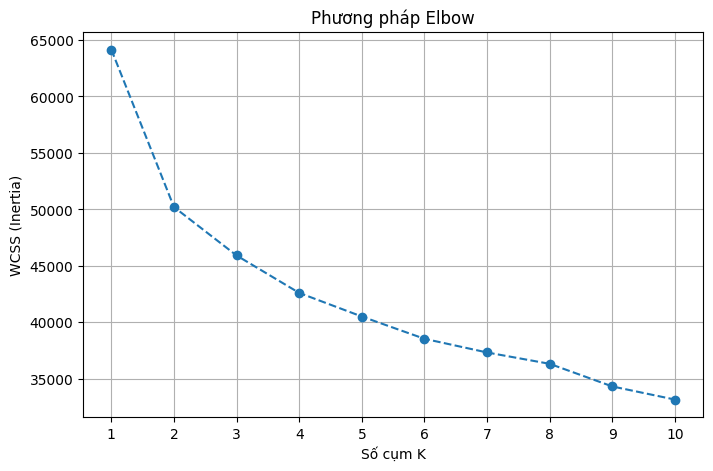

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Chỉ lấy các cột dữ liệu dạng số (loại bỏ cột Dt_Customer)
X_cluster = customer_data.select_dtypes(include=['number'])

# 2. Chạy phương pháp Elbow
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    wcss.append(kmeans.inertia_)

# 3. Vẽ biểu đồ Elbow
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.title('Phương pháp Elbow')
plt.xlabel('Số cụm K')
plt.ylabel('WCSS (Inertia)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

Sử dụng thư viện yellowbrick

In [ ]:
from yellowbrick.cluster import KElbowVisualizer

In [ ]:
# TODO

**Phân cụm từ kết quả của phương pháp Elbow**

In [ ]:
# TODO
from sklearn.cluster import KMeans

# 1. Chỉ lấy các cột kiểu số (đã chuẩn hóa và bỏ cột Dt_Customer)
X_cluster = customer_data.select_dtypes(include=['number'])

# 2. Chọn số cụm K tối ưu từ biểu đồ Elbow (Ví dụ K = 3)
K_opt = 3

# 3. Khởi tạo và huấn luyện mô hình K-Means
kmeans = KMeans(n_clusters=K_opt, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

# 4. Gán kết quả phân cụm vào cột mới 'Cluster' trong dataset
customer_data['Cluster'] = cluster_labels

# Kiểm tra số lượng khách hàng trong mỗi cụm
print(customer_data['Cluster'].value_counts())

Cluster
2    1241
1     772
0     199
Name: count, dtype: int64


**Sử dụng PCA giảm số chiều dữ liệu --> trực quan hoá kết quả phân cụm**

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
# Biến đổi dữ liệu sang không gian 2 chiều pca
# TODO
import pandas as pd
from sklearn.decomposition import PCA

# 1. Chỉ chọn các cột dữ liệu dạng số (loại bỏ cột Dt_Customer nếu còn)
# Nếu cột 'Cluster' đã được thêm ở bước trước, ta bỏ cột 'Cluster' ra khỏi quá trình PCA
X_pca = customer_data.select_dtypes(include=['number']).drop(
    columns=['Cluster'], errors='ignore'
)

# 2. Khởi tạo PCA với 2 thành phần chính
pca = PCA(n_components=2, random_state=42)
pca_features = pca.fit_transform(X_pca)

# 3. Lưu kết quả PCA vào DataFrame để dễ vẽ biểu đồ
customer_data['PCA1'] = pca_features[:, 0]
customer_data['PCA2'] = pca_features[:, 1]

# Kiểm tra tỉ lệ phương sai được giữ lại bởi 2 thành phần chính
print(
    'Tỷ lệ phương sai giải thích (Explained Variance Ratio):',
    pca.explained_variance_ratio_,
)
print('Tổng lượng thông tin giữ lại:', sum(pca.explained_variance_ratio_))

Tỷ lệ phương sai giải thích (Explained Variance Ratio): [0.28206988 0.09665901]
Tổng lượng thông tin giữ lại: 0.3787288903397121


**Trực quan hoá kết quả phân cụm**

In [ ]:
def visualize_cluster_result(scores, labels):
    '''
    Args:
        scores: biến đổi pca 2d
        labels: nhãn của từng điểm dữ liệu trong scores (chính là label của kết quả phân cụm)
    '''
    # TODO
    fig1, (axes) = plt.subplots(figsize=(8,8))
    scat_1 = sns.scatterplot(
                            x=scores[:,0],
                            y=scores[:,1],
                            hue=labels, ax=axes,
                            palette='Set1', legend='full'
            )
    plt.show()

#### Phân tích kết quả phân cụm (KMeans)

In [ ]:
# Gán kết quả phân cụm vào df ban đầu ~ customer_data
from sklearn.cluster import KMeans
# 1. Khởi tạo và huấn luyện mô hình KMeans (ví dụ chọn n_clusters=3 từ biểu đồ Elbow)
X_cluster = customer_data.select_dtypes(include=['number'])
kmean = KMeans(n_clusters=3, random_state=42, n_init=10)
kmean.fit(X_cluster)


kmean_df = customer_data.copy()
kmean_df['Cluster'] = kmean.labels_
kmean_df.head()

,Year_Birth,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Cluster,PCA1,PCA2
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,-1.018352,-1.349603,0.287105,-0.822754,-0.929699,2012-09-04,0.310353,0.977660,1.552041,1.690293,2.453472,1.483713,0.852576,0.351030,1.426865,2.503607,-0.555814,0.692181,-0.282048,-0.282981,-0.280175,-0.261914,-0.117256,-0.09552,0.0,0.0,2.375425,1.018352,1.527721,-1.758359,0.617244,1.676245,False,True,False,False,2,4.545708,-0.145988
2174,-1.274785,-1.349603,-0.260882,1.040021,0.908097,2014-03-08,-0.380813,-0.872618,-0.637461,-0.718230,-0.651004,-0.634019,-0.733642,-0.168701,-1.126420,-0.571340,-1.171160,-0.132545,-0.282048,-0.282981,-0.280175,-0.261914,-0.117256,-0.09552,0.0,0.0,-0.420977,1.274785,-1.189011,0.449070,-0.502808,-0.963297,False,True,False,False,1,-2.592809,-0.922126
4141,-0.334530,0.740959,0.913196,-0.822754,-0.929699,2013-08-21,-0.795514,0.357935,0.570540,-0.178542,1.339513,-0.147184,-0.037254,-0.688432,1.426865,-0.229679,1.290224,-0.544908,-0.282048,-0.282981,-0.280175,-0.261914,-0.117256,-0.09552,0.0,0.0,-0.420977,0.334530,-0.206048,-0.654644,-0.502808,0.280110,False,True,False,False,0,1.583999,-0.887501
6182,1.289547,0.740959,-1.176114,1.040021,-0.929699,2014-02-10,-0.795514,-0.872618,-0.561961,-0.655787,-0.504911,-0.585335,-0.752987,-0.168701,-0.761665,-0.913000,-0.555814,0.279818,-0.282048,-0.282981,-0.280175,-0.261914,-0.117256,-0.09552,0.0,0.0,-0.420977,-1.289547,-1.060584,0.449070,-0.502808,-0.920135,False,True,False,False,1,-2.932029,1.617107
5324,1.033114,0.740959,0.294307,1.040021,-0.929699,2014-01-19,1.554453,-0.392257,0.419540,-0.218684,0.152508,-0.001133,-0.559545,1.390492,0.332600,0.111982,0.059532,-0.132545,-0.282048,-0.282981,-0.280175,-0.261914,-0.117256,-0.09552,0.0,0.0,-0.420977,-1.033114,-0.951915,0.449070,-0.502808,-0.307562,False,False,False,True,1,-0.810183,0.247034


In [ ]:
def visualize_cluster_distribution(labels):
    '''
    Args:
        labels: kết quả phân cụm (danh sách nhãn)
    '''
    ulabels, count = np.unique(labels, return_counts=True)
    plt.figure(figsize=(6,4))

    colors = sns.color_palette('Set2')[0:5]
    
    labels = [f'Cluster {i+1}' for i in range(len(ulabels))]
    plt.pie(count, 
            explode=[0.05]*len(ulabels), 
            labels=labels,
            colors=colors,
            autopct='%1.1f%%',
            textprops=dict(color ="white", fontsize=10),
            counterclock=False,
            startangle=180,
            wedgeprops={"edgecolor":"gray",'linewidth': 1}
        )

    plt.axis('equal')
    plt.legend()
    plt.show()

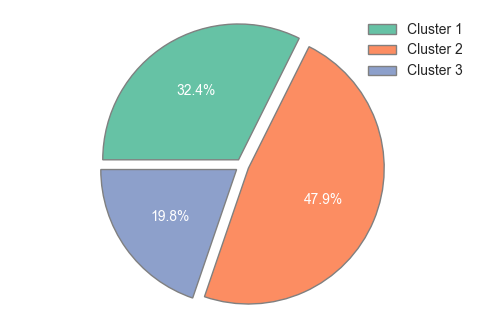

In [ ]:
visualize_cluster_distribution(kmean.labels_)

**Phân tích đa biến + kết quả phân cụm**

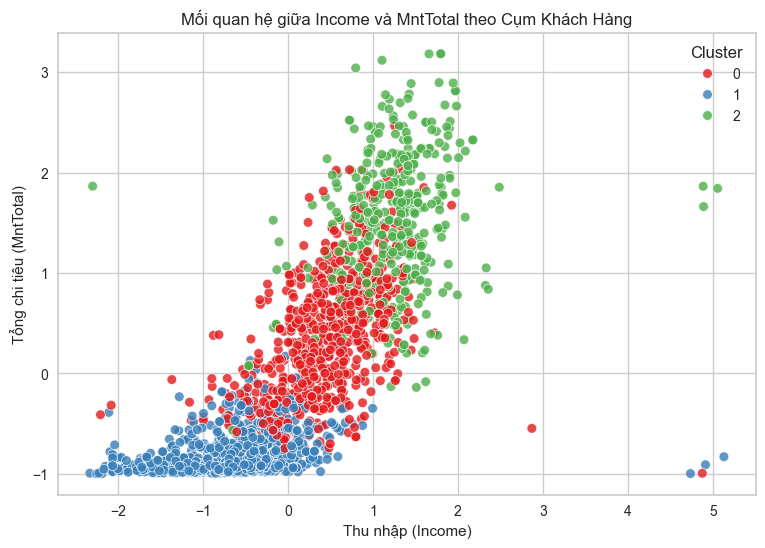

In [ ]:
# đặc trưng income và MntTotal: vẽ sns scatterplot với hue là Cluster
# TODO
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ scatterplot biểu diễn mối quan hệ giữa Income và MntTotal theo Cluster
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x='Income',
    y='MntTotal',
    hue='Cluster',
    data=kmean_df,
    palette='Set1',
    alpha=0.8,
)

plt.title('Mối quan hệ giữa Income và MntTotal theo Cụm Khách Hàng')
plt.xlabel('Thu nhập (Income)')
plt.ylabel('Tổng chi tiêu (MntTotal)')
plt.grid(True)
plt.show()

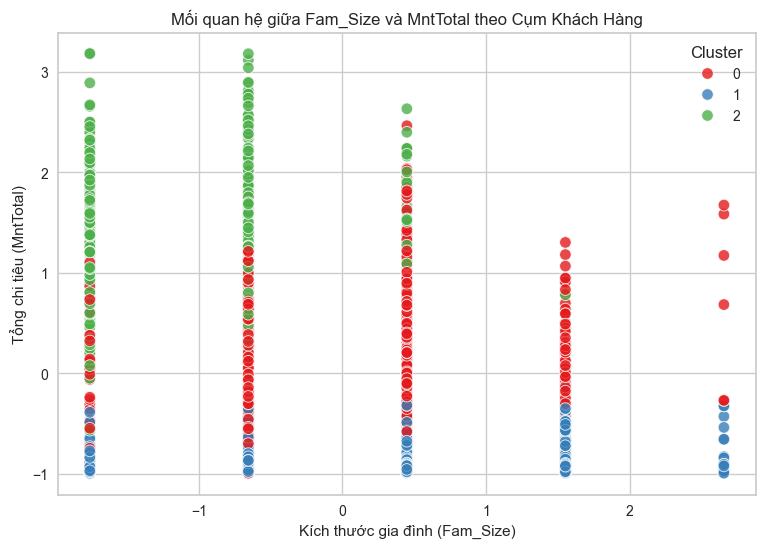

In [ ]:
# đặc trưng Fam_Size và MntTotal: vẽ sns scatterplot với hue là Cluster
# TODO
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ scatterplot giữa Fam_Size và MntTotal theo Cluster
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x='Fam_Size',
    y='MntTotal',
    hue='Cluster',
    data=kmean_df,
    palette='Set1',
    alpha=0.8,
    s=70,
)

plt.title('Mối quan hệ giữa Fam_Size và MntTotal theo Cụm Khách Hàng')
plt.xlabel('Kích thước gia đình (Fam_Size)')
plt.ylabel('Tổng chi tiêu (MntTotal)')
plt.grid(True)
plt.show()

**Phân tích danh mục mua hàng**

--- Mức chi tiêu trung bình theo danh mục sản phẩm ---


,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Cluster,,,,,,
0,0.44,0.17,0.02,0.15,0.16,0.37
1,-0.76,-0.53,-0.63,-0.56,-0.53,-0.53
2,1.12,1.01,1.48,1.11,1.03,0.67


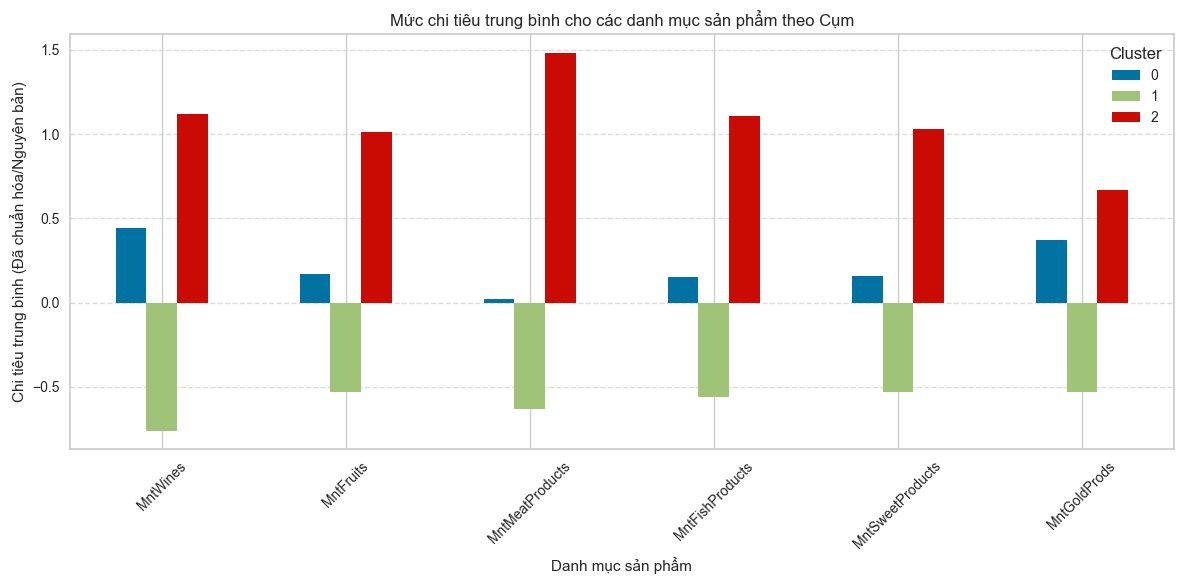

In [ ]:
# TODO
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Danh sách các cột danh mục sản phẩm (MntXXX)
mnt_cols = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
]

# 2. Tính mức chi tiêu trung bình theo từng Cụm
category_analysis = kmean_df.groupby('Cluster')[mnt_cols].mean().round(2)
print('--- Mức chi tiêu trung bình theo danh mục sản phẩm ---')
display(category_analysis)

# 3. Trực quan hóa bằng biểu đồ cột (Grouped Bar Chart)
category_analysis.T.plot(kind='bar', figsize=(12, 6))
plt.title('Mức chi tiêu trung bình cho các danh mục sản phẩm theo Cụm')
plt.xlabel('Danh mục sản phẩm')
plt.ylabel('Chi tiêu trung bình (Đã chuẩn hóa/Nguyên bản)')
plt.xticks(rotation=45)
plt.legend(title='Cluster')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### A7. Kết hợp PCA và phân cụm
- Biến đổi PCA với số lượng component phù hợp (giữ lại 70-80% thông tin ban đầu).
- Ước lượng số cụm dùng elbow (dùng dữ liệu pca).
- Với số cụm phù hợp, thực hiện phân cụm trên dữ liệu pca.
- Vẽ phân bố kết quả phân cụm.
- Vẽ biểu đồ scatter MntTotal-Income-Cluster.

In [ ]:
# vẽ biểu đồ sreeplot
def scree_plot(pca_model, xlabels):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # explained variance ratio của mô hình pca
    expl_var_ratio = pca_model.explained_variance_ratio_
    # tính cumulative sum của expl_var_ratio (numpy.cumsum)
    expl_var_cumsum = np.cumsum(expl_var_ratio)
    xtick_indx = range(1, len(expl_var_ratio) + 1)
    
    # vẽ các bar thể hiện explained_var
    ax.bar(xtick_indx, expl_var_ratio)
    ax.plot(xtick_indx, expl_var_cumsum, marker='o', color='k')
    
    # set label
    ax.set_xticks(xtick_indx)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel('Principle Components')
    ax.set_ylabel('% variance')
    ax.set_title('Scree Plot')
    
    plt.grid(True)

In [ ]:
#scree_plot(pca, [f'pc{i+1}' for i in range(len(df.columns))])

In [ ]:
# biến đổi df sang không gian pca 4 chiều

# TODO
# 1. Chỉ lấy các cột dữ liệu dạng số (loại bỏ cột Dt_Customer nếu có)
X_pca = customer_data.select_dtypes(include=['number'])

# 2. Khởi tạo PCA với 4 thành phần chính
pca_4d = PCA(n_components=4, random_state=42)

# 3. Biến đổi dữ liệu sang không gian 4 chiều
pca_transformed_4d = pca_4d.fit_transform(X_pca)

# (Tùy chọn) Kiểm tra tỷ lệ phương sai tích lũy của 4 thành phần chính
print(
    'Tỷ lệ phương sai giải thích tích lũy (4D):',
    sum(pca_4d.explained_variance_ratio_),
)

Tỷ lệ phương sai giải thích tích lũy (4D): 0.6598631251558613


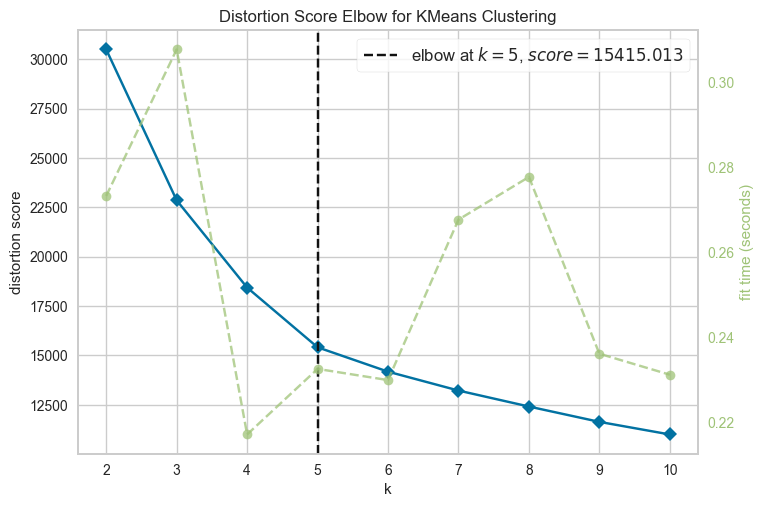

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

# 1. Khởi tạo mô hình
model = KMeans(n_init=20, random_state=99)

# 2. Thêm force_model=True và đổi k thành khoảng (2, 11)
visualizer = KElbowVisualizer(model, k=(2, 11), force_model=True)

# 3. Fit và hiển thị
visualizer.fit(pca_transformed_4d)
visualizer.show()

In [ ]:
# Gán kết quả phân cụm vào df ban đầu ~ customer_data
kmean_pca_df = customer_data.copy()
kmean_pca_df['Cluster'] = kmean.labels_
kmean_pca_df.head()

,Year_Birth,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Cluster,PCA1,PCA2
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,-1.018352,-1.349603,0.287105,-0.822754,-0.929699,2012-09-04,0.310353,0.977660,1.552041,1.690293,2.453472,1.483713,0.852576,0.351030,1.426865,2.503607,-0.555814,0.692181,-0.282048,-0.282981,-0.280175,-0.261914,-0.117256,-0.09552,0.0,0.0,2.375425,1.018352,1.527721,-1.758359,0.617244,1.676245,False,True,False,False,2,4.545708,-0.145988
2174,-1.274785,-1.349603,-0.260882,1.040021,0.908097,2014-03-08,-0.380813,-0.872618,-0.637461,-0.718230,-0.651004,-0.634019,-0.733642,-0.168701,-1.126420,-0.571340,-1.171160,-0.132545,-0.282048,-0.282981,-0.280175,-0.261914,-0.117256,-0.09552,0.0,0.0,-0.420977,1.274785,-1.189011,0.449070,-0.502808,-0.963297,False,True,False,False,1,-2.592809,-0.922126
4141,-0.334530,0.740959,0.913196,-0.822754,-0.929699,2013-08-21,-0.795514,0.357935,0.570540,-0.178542,1.339513,-0.147184,-0.037254,-0.688432,1.426865,-0.229679,1.290224,-0.544908,-0.282048,-0.282981,-0.280175,-0.261914,-0.117256,-0.09552,0.0,0.0,-0.420977,0.334530,-0.206048,-0.654644,-0.502808,0.280110,False,True,False,False,0,1.583999,-0.887501
6182,1.289547,0.740959,-1.176114,1.040021,-0.929699,2014-02-10,-0.795514,-0.872618,-0.561961,-0.655787,-0.504911,-0.585335,-0.752987,-0.168701,-0.761665,-0.913000,-0.555814,0.279818,-0.282048,-0.282981,-0.280175,-0.261914,-0.117256,-0.09552,0.0,0.0,-0.420977,-1.289547,-1.060584,0.449070,-0.502808,-0.920135,False,True,False,False,1,-2.932029,1.617107
5324,1.033114,0.740959,0.294307,1.040021,-0.929699,2014-01-19,1.554453,-0.392257,0.419540,-0.218684,0.152508,-0.001133,-0.559545,1.390492,0.332600,0.111982,0.059532,-0.132545,-0.282048,-0.282981,-0.280175,-0.261914,-0.117256,-0.09552,0.0,0.0,-0.420977,-1.033114,-0.951915,0.449070,-0.502808,-0.307562,False,False,False,True,1,-0.810183,0.247034


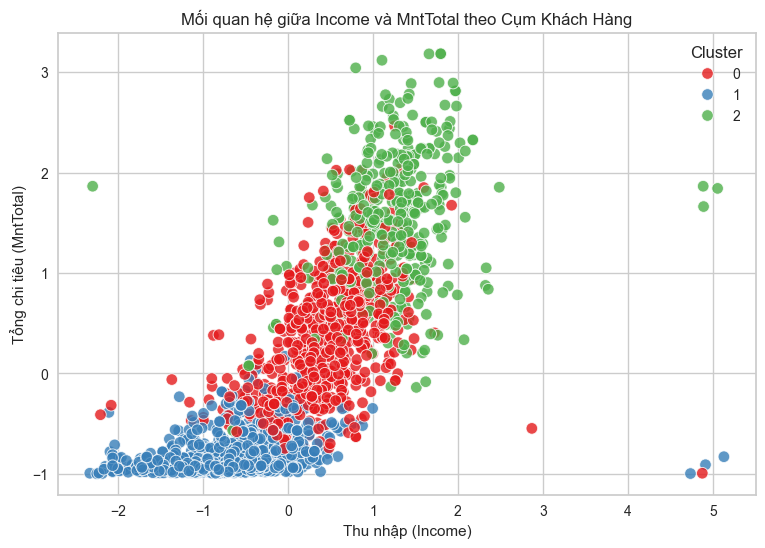

In [ ]:
# đặc trưng income và MntTotal: vẽ sns scatterplot với hue là Cluster
# TODO
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ scatterplot biểu diễn mối quan hệ giữa Income và MntTotal theo Cluster
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x='Income',
    y='MntTotal',
    hue='Cluster',
    data=kmean_df,
    palette='Set1',
    alpha=0.8,
    s=70,
)

plt.title('Mối quan hệ giữa Income và MntTotal theo Cụm Khách Hàng')
plt.xlabel('Thu nhập (Income)')
plt.ylabel('Tổng chi tiêu (MntTotal)')
plt.grid(True)
plt.show()

#### A9. Phân tích kết quả phân cụm (DBSCAN)

In [ ]:
from sklearn.cluster import DBSCAN

**Sử dụng knee plot để ước lượng eps**

In [ ]:
len(df.columns)

11

In [ ]:
from sklearn.neighbors import NearestNeighbors
def knee_plot(n_neighs, data):
    neigh = NearestNeighbors(n_neighbors=n_neighs)
    nbrs = neigh.fit(data)
    distances, indices = nbrs.kneighbors(data)

    # plot
    distances = np.sort(distances, axis=0)
    distances = distances[:,1]
    plt.plot(distances)
    
    return distances

**Sử dụng PCA thu giảm số chiều --> phân cụm**

**Chia nhỏ đặc trưng**

In [ ]:
sub_df = df[['Income', 'MntTotal', 'Enroll_days']]

### B. Dữ liệu taxi 

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('data/taxi_data.csv')
df.head()

,LON,LAT,NAME
0,28.17858,-25.73882,11th Street Taxi Rank
1,28.17660,-25.73795,81 Bazaar Street Taxi Rank
2,27.83239,-26.53722,Adams Road Taxi Rank
3,28.12514,-26.26666,Alberton City Mall Taxi Rank
4,28.10144,-26.10567,Alexandra Main Taxi Rank


**Biểu diễn giá trị toạ độ trên bản đồ**

In [ ]:
import folium, re

In [ ]:
X = df[['LAT','LON']].values
m = folium.Map(location=[X[:,0].mean(), X[:,1].mean()], tiles='Stamen Toner', zoom_start=10)

In [ ]:
for _,row in df.iterrows():
    folium.CircleMarker(
        location=[row.LAT,row.LON],
        radius=5,
        popup=re.sub(r'\W+',' ',row.NAME),
        fill=True
    ).add_to(m)

# Loại bỏ non-word chars
title = '''<h3 align="center" style="font-size:30px"><b>Given Data</b></h3>'''
m.get_root().html.add_child(folium.Element(title))
m

In [ ]:
# Knee plot để ước lượng eps

In [ ]:
#First create an array of color schemes
colors = ['royalblue', 'maroon', 'forestgreen', 'mediumorchid', 'tan', 'deeppink', 
          'olive', 'goldenrod', 'lightcyan', 'navy','springgreen','midnightblue',
         'red','brown','limegreen','lime','pink','orchid','crimson','m']*10

In [ ]:
# Sử dụng DBSCAN để phân cụm

In [ ]:
def create_map(cluster_column, colors_column, title):
    m = folium.Map(location=[X[:,0].mean(),X[:,1].mean()],tiles='Stamen Toner',zoom_start=8.5)
    for _,row in df.iterrows():
        folium.CircleMarker(
            location=[row.LAT,row.LON],
            radius=5,
            popup=row[cluster_column],
            fill=True,
            color=row[colors_column],
            fill_color=row[colors_column],
        ).add_to(m)

    print(title)
    return m